In [1]:
!pip install pandas
!pip install openpyxl


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Importing Dataset


**Why this step matters:**
Before any analysIS, we need to load our dataset into python.

Python alone needs lots of codes to read datasets, however with `pandas` library we can do this with just one line.


**What i do:**
So base on our project we use `pd.read_excel` to load efficiency dataset from our Excel file to access the required data.

After loading, we check basic structure using `.shape` and `head()`.


**Key findings:**
- The dataset contains **`768`** rows (each represent a building) and **`10`** columns.
- The first few rows also show that all features are numeric, which privent us from converting dat for modeling.


**Next step:** 
I rename the colums to make them more descriptive and easier to work with.

In [2]:
import pandas as pd

#loading excel file into dataframe
df= pd.read_excel('ENB2012_data.xlsx')

print("(the number of columns, the number of rows): ")

#show the number of rows and columns
print(df.shape)

(the number of columns, the number of rows): 
(768, 10)


## Rename Columns

**Why this step matters:**
The original dataset uses x1 , x2 etc to represent the features so should do something to understand what they excatly represents.

**What i do:**
I rename all columns based on their actual meaning to analysis easier.
for instance:

-`x1` -> `Relative Compactness`

-`y1` -> `Heating Load`

**Key result:**
So whenever we use a column we immediately know what it refers to and it makes our analysis more professional.

**Next step:**
Now we start visualizing the distributions.

In [3]:
df.columns=['X1:Relative-compactness','X2:Surface-area','X3:Wall-area','X4:Roof-area', 'X5:Overall-height', 'X6:Orientation', 'X7:Glazing-area',
            'X8:Glazing-dist', 'Y1:Heating-load', 'Y2:Cooling-load']

print("the first 5 row of data with new names:")

#showing first 5 rows
print(df.head())

the first 5 row of data with new names:
   X1:Relative-compactness  X2:Surface-area  X3:Wall-area  X4:Roof-area  \
0                     0.98            514.5         294.0        110.25   
1                     0.98            514.5         294.0        110.25   
2                     0.98            514.5         294.0        110.25   
3                     0.98            514.5         294.0        110.25   
4                     0.90            563.5         318.5        122.50   

   X5:Overall-height  X6:Orientation  X7:Glazing-area  X8:Glazing-dist  \
0                7.0               2              0.0                0   
1                7.0               3              0.0                0   
2                7.0               4              0.0                0   
3                7.0               5              0.0                0   
4                7.0               2              0.0                0   

   Y1:Heating-load  Y2:Cooling-load  
0            15.55        

In [4]:
!pip install matplotlib
!pip install seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Histogram for Target Variables

**Why this step matters:**
To build a good predictive model, we need to understand the distribution of our target variables (Heating Load and Cooling Load). 

**What I do:**
I use `sns.histplot()` to draw histograms for both targets. 
A histogram separates and groups the dataset into specific intervals (bins) and shows how many samples fall into each range. 
I also customized the diagrams with appropriate colors, font sizes, and axis labels to make them clear.

**Key findings:**
- Both target variables show a roughly `normal distribution`.

**Next step:** 
Now I will examine the relationship between features and targets using a correlation matrix.


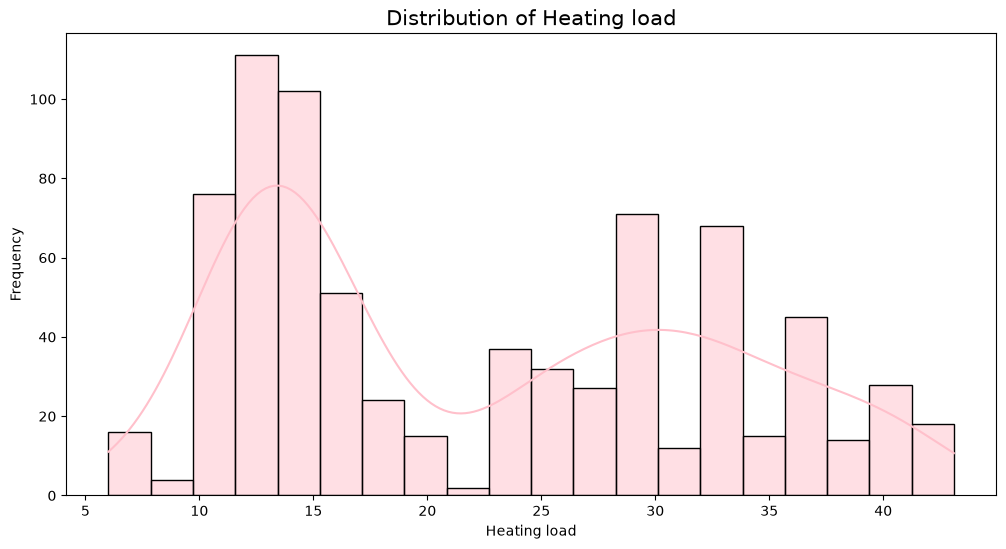

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

#diagram size
plt.figure(figsize=(12,6))
sns.histplot(df['Y1:Heating-load'], bins=20, kde=True, color='pink')
plt.title('Distribution of Heating load', fontsize=15)
plt.xlabel('Heating load')
plt.ylabel('Frequency')
plt.show()

## Correlation Matrix

**Why this step matters:**
To understand which features have the most influence on energy consumption, we need to measure the linear relationship between each feature and the target variables (Heating Load and Cooling Load). 
This helps us identify the most important predictors to avoid multicollinearity in our models.

**What I do:**
I use `sns.heatmap()` to visualize the correlation matrix of all features and targets. 
The color intensity shows the strength and direction of the relationship:
- **Red** indicates a strong positive correlation.
- **Blue** indicates a strong negative correlation.

**Key findings:**
Based on the correlation matrix (see the heatmap bellow):
- **X5_Overall_Height** has the strongest correlation with both targets (`-0.88`). 
  This means taller buildings consume significantly less energy.
- **X2_Surface_Area** shows a strong positive correlation (`0.62`), 
  meaning larger surface areas lead to higher energy consumption.
- **X7_Glazing_Area** has a moderate correlation with Cooling Load.

**Next step:** 
Now I will visualize these key relationships using scatter plots to confirm the nature of the relationships.

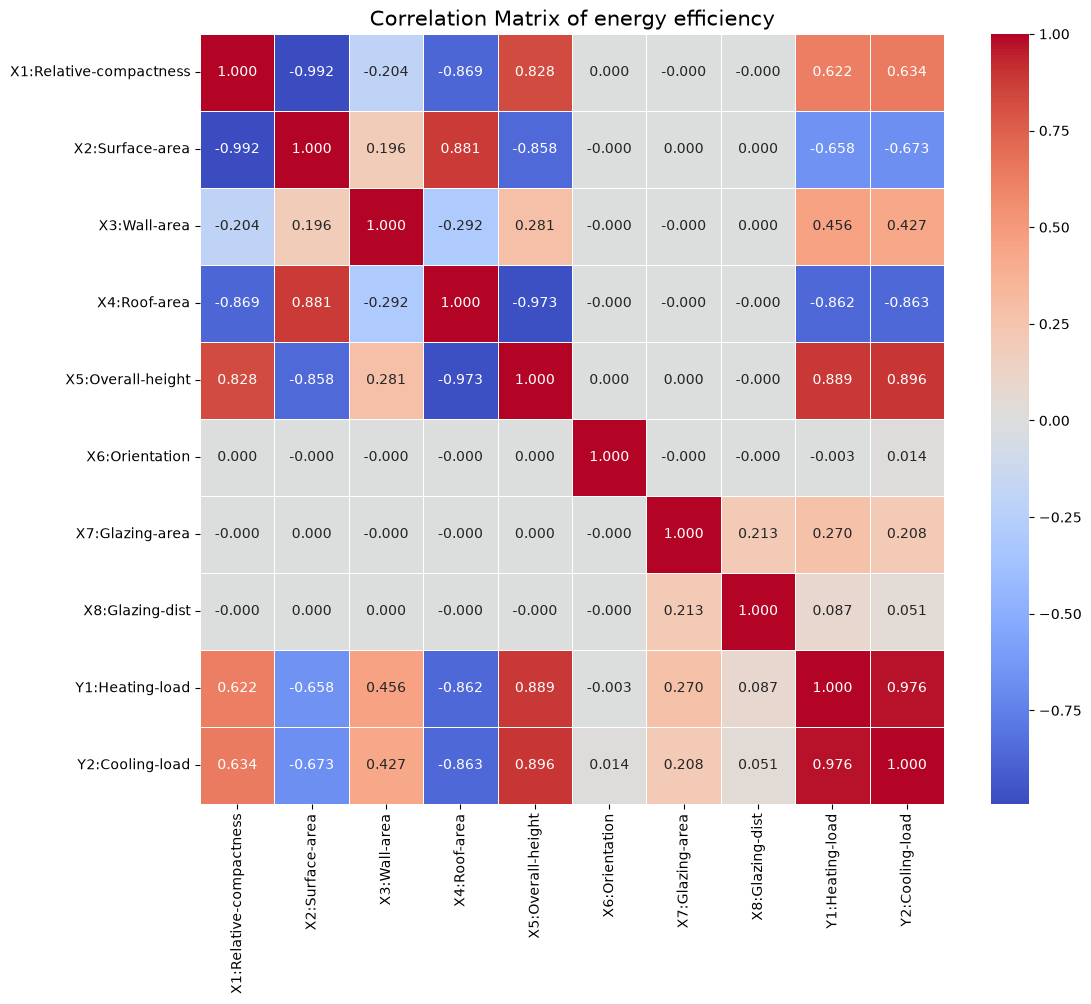

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

# Draw a colorful heatmap showing correlation coefficients between each pair of features
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Correlation Matrix of energy efficiency', fontsize=15)
plt.show()

## Correlation Values for Target Variables

**Why this step matters:**
After visualizing the correlation matrix, it is helpful to see the exact correlation coefficients in a sorted list. 
This allows us to quickly identify which features are most strongly associated with each target.

**What I do:**
I extract the correlation values of all features with `Heating Load` and `Cooling Load`, and sort them in descending order (from highest to lowest correlation).

**Key findings:**
Based on the sorted lists:
- **X5:Overall-height** has the strongest negative correlation with both targets (≈ **-0.88**).
- **X2:Surface-area** shows a strong positive correlation (≈ **0.62**).

**Next step:** 
I will use scatter plots to visually confirm these relationships before building predictive models.

In [7]:
#
corr_heating = df.corr()['Y1:Heating-load'].sort_values(ascending=False)
print("== Correlation with Heating load =="+ "\n")
print(corr_heating)

print("\n" + "="*153 + "\n")

corr_cooling = df.corr()['Y2:Cooling-load'].sort_values(ascending=False)
print("== Correlation with Cooling load ==" + "\n")
print(corr_cooling)

== Correlation with Heating load ==

Y1:Heating-load            1.000000
Y2:Cooling-load            0.975862
X5:Overall-height          0.889430
X1:Relative-compactness    0.622272
X3:Wall-area               0.455671
X7:Glazing-area            0.269842
X8:Glazing-dist            0.087368
X6:Orientation            -0.002587
X2:Surface-area           -0.658120
X4:Roof-area              -0.861828
Name: Y1:Heating-load, dtype: float64


== Correlation with Cooling load ==

Y2:Cooling-load            1.000000
Y1:Heating-load            0.975862
X5:Overall-height          0.895785
X1:Relative-compactness    0.634339
X3:Wall-area               0.427117
X7:Glazing-area            0.207505
X8:Glazing-dist            0.050525
X6:Orientation             0.014290
X2:Surface-area           -0.672999
X4:Roof-area              -0.862547
Name: Y2:Cooling-load, dtype: float64


## Scatter Plots for Key Features

**Why this step matters:**
While correlation numbers are useful, visual inspection helps us understand the nature of the relationship (linear, non-linear, or no relationship). 
This guides our choice of regression models.

**What I do:**
I use `sns.scatterplot()` to visualize the relationship between the most important features and our target variables:
- **Overall Height** vs Heating Load / Cooling Load
- **Surface Area** vs Heating Load / Cooling Load

**Key findings:**
- There is a clear **negative linear relationship** between height and both heating/cooling loads. 
- There is a **positive linear relationship** between surface area and both targets. 

**Next step:** 
Based on these findings, I will proceed to feature engineering and model building. 
Linear models should perform well, but We will also test non-linear models like Random Forest and XGBoost to compare their performance.

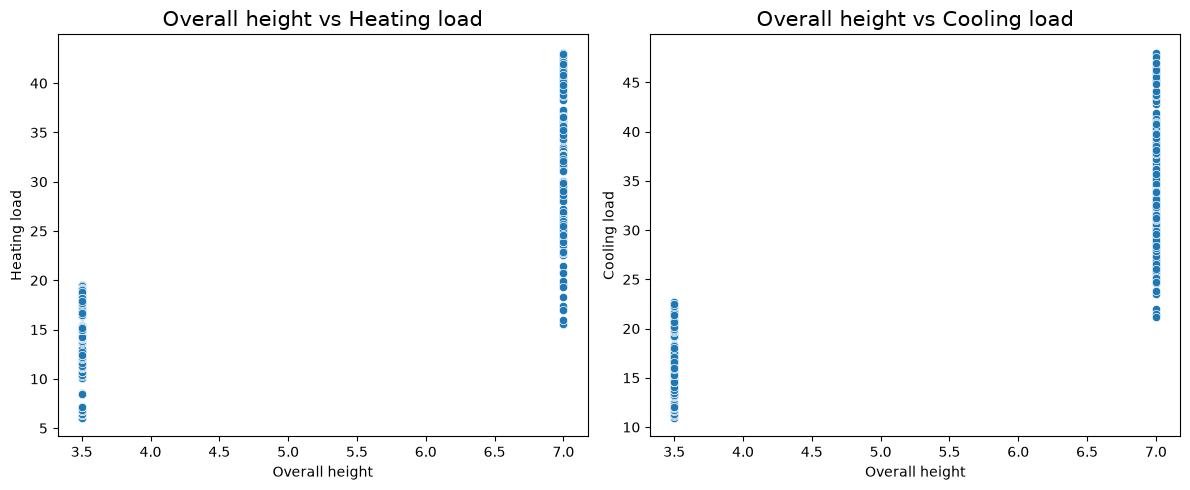

In [8]:
plt.figure(figsize=(12, 5))

# in a row with two diagrams we set the first one on the left
plt.subplot(1, 2, 1)

sns.scatterplot(x=df['X5:Overall-height'], y=df['Y1:Heating-load'])
plt.title('Overall height vs Heating load', fontsize=15)
plt.xlabel('Overall height')
plt.ylabel('Heating load')


plt.subplot(1, 2, 2)

# we define a scatterplot with axis of lengths (overall-height) and width (cooling-load)
sns.scatterplot(x=df['X5:Overall-height'], y=df['Y2:Cooling-load'])

plt.title('Overall height vs Cooling load', fontsize=15)
plt.xlabel('Overall height')
plt.ylabel('Cooling load')

# defining the distance between margins and the diagrams
plt.tight_layout()
plt.show()

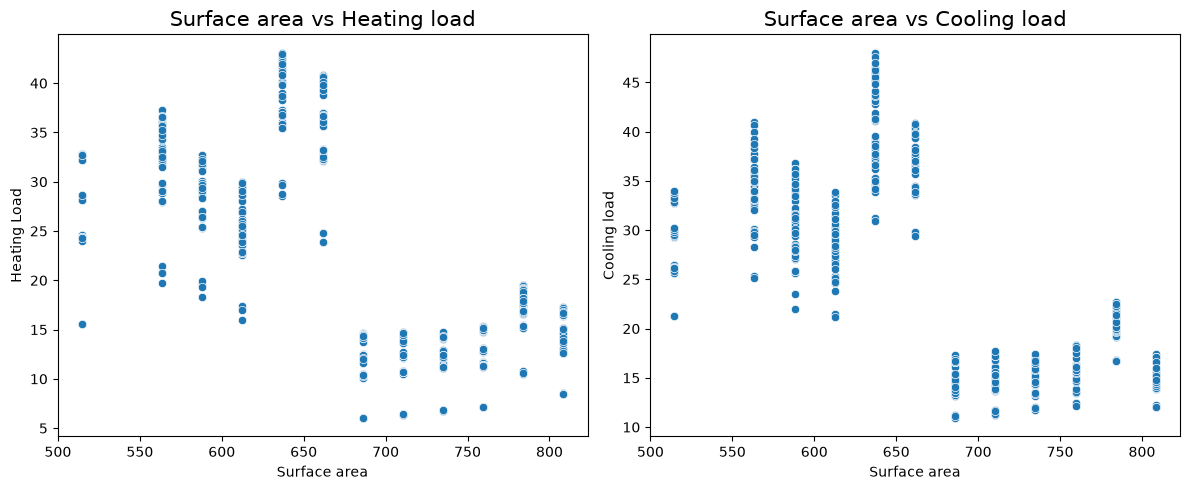

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=df['X2:Surface-area'], y=df['Y1:Heating-load'])
plt.title('Surface area vs Heating load', fontsize=15)
plt.xlabel('Surface area')
plt.ylabel('Heating Load')

plt.subplot(1, 2, 2)
sns.scatterplot(x=df['X2:Surface-area'], y=df['Y2:Cooling-load'])
plt.title('Surface area vs Cooling load', fontsize=15)
plt.xlabel('Surface area')
plt.ylabel('Cooling load')

plt.tight_layout()
plt.show()

## building predictive models

**why this step matters:**
the goal of this project is to creat model that can predict heating load based on building characteristics to somehow help engineers design more energy efficient buildings.


**what i do:**
I will compare four different model for our dataset:
1. `linear regression` - as a baseline
2. `ridge regression` - to prevent overfitting
3. `random forest` - to capture non linear patterns
4. `xgboost` - powerful for tabular data


**how we will evaluate them:**

I will use two matrics:

- `rmse`= lower is better

- `R² score` = closer to 1 is better


**next step:**
repare the data for modeling

In [10]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Deleting two colums of y1 and y2
X = df.drop(['Y1:Heating-load', 'Y2:Cooling-load'], axis=1)
y = df['Y1:Heating-load']  

#Devide 4 groups with 20 percent for test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Standard the numeric data (to have 0 mean and one variance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print(f" Training samples: {X_train_scaled.shape[0]}")
print(f" Test samples: {X_test_scaled.shape[0]}")
print(f" Features: {X_train_scaled.shape[1]}")

 Training samples: 614
 Test samples: 154
 Features: 8


## Linear Regression (Baseline Model)

**Why this step matters:**
Before building complex model we draw linear regression to show the relationship between descriptive variables and the response variable.

**What I do:**
I train a linear regression model and evaluate it using `RMSE` and `R²`.

**Key result:**
The results will show whether a linear relationship is enough or if I need more complex models.

**Next step:**
I will compare this with Ridge Regression to see if regularization improves performance.

In [12]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#Create and train the model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

#Evaluate the model
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"RMSE: {rmse_lr:.3f}")
print(f"R² Score: {r2_lr:.3f}")

RMSE: 3.025
R² Score: 0.912


## Linear Regression Results

**Key results:**
- RMSE: [3.025]
- R² Score: [0.912]

**Next step:**
I will try Ridge Regression to see if regularization improves performance.

========================================================================================================================================================

## Ridge Regression

**Why this step matter:**
Our model for linear regression will overfit on defined data well although for test new data it will perform poorly especially when features have high correlation. in this case i use ridge regression which add a penalty make our model more simple.

**What i do:**
I train a ridge regression model with `1.0 alpha` (evaluated by rmse and R²)

- `alpha > 0` vs `alpha = 0` : in the first one penalty added and model become more simple but the second one is for linear regression

**Next step:**
I will compare this model with random forest to see which model performs better.

In [13]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("=== Ridge Regression Results ==="+"\n")
print(f"RMSE: {rmse_ridge:.3f}")
print(f"R² Score: {r2_ridge:.3f}")

=== Ridge Regression Results ===

RMSE: 3.035
R² Score: 0.912


## Random Forest

**Why this step matter:**
Not all relationships are linear.
In real-world data , relationships are often non-linear.
To capture complex relationship between features and target variables we use random forest


**What I do:**
I trained a random forest with 100 trees with using RMSE and R².

**Next step:**
I will compare this model with xgboost to see which one performs better.

In [14]:
from sklearn.ensemble import RandomForestRegressor

# Create and train the model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)


y_pred_rf = rf.predict(X_test_scaled)

#Evaluate the model
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Random Forest Results ==="+"\n")
print(f"RMSE: {rmse_rf:.3f}")
print(f"R² Score: {r2_rf:.3f}")

=== Random Forest Results ===

RMSE: 0.493
R² Score: 0.998


## Random Forest Results

**Key results:**
- `RMSE` 0.493
- `R² Score` 0.998

**Interpretation:**
The Random Forest model achieved 0.998 score, it means it's near to 99.8% and it explains nearly 99.8% of the variance in the data.
Moreover RMSE contains 0.5 error which shows our result is so trustable.

**Next step:**
I will now train an XGBoost model to see it will achieve similar or better performance, and finally compare all models in a final table later.

## XGBoost

**Why this step matters:**
For working with tabular data we should train our model with the best one, XGBoost is one of the strongest models in machine learning.

**What I do:**
I train an XGBoost model with 100 estimators and a learning rate of 0.1.

**Next step:**
I will compare all previous models and XGBoost in a final comparison table.

In [17]:
!pip install xgboost


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("=== XGBoost Results ==="+"\n")
print(f"RMSE: {rmse_xgb:.3f}")
print(f"R² Score: {r2_xgb:.3f}")

=== XGBoost Results ===

RMSE: 0.407
R² Score: 0.998
